## SECTION 0 — Setup & Imports

In [1]:
!pip3 install opencv-python-headless pandas matplotlib seaborn scikit-learn lightgbm timm pvlib psutil pytz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 135.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 181.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 188.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 167.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 6.1 MB/s eta 0:00:00a 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 179.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 86.3 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import os, time, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import timm
from PIL import Image
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
warnings.filterwarnings("ignore")

# ── Paths (auto-detect: RunPod /workspace or local project folder) ────────────
import sys
ROOT = "/workspace" if os.path.exists("/workspace") else os.path.abspath(".")

BASE_DIR = f"{ROOT}/data"
SAT_DIR  = f"{ROOT}/data/satellite"
NPY_DIR  = f"{ROOT}/data/satellite_npy"
CSV_PATH = "combined_dataset.csv"
RESULTS  = f"{ROOT}/results"

os.makedirs(f"{RESULTS}/plots", exist_ok=True)
os.makedirs(NPY_DIR, exist_ok=True)
print(f"ROOT: {ROOT}")

# ── Model definitions come from model.py (single source of truth) ─────────────
# Upload model.py alongside this notebook. predict.py/verify.py use the SAME
# classes, so a checkpoint trained here always loads for inference.
sys.path.insert(0, ROOT)
assert os.path.exists("model.py"), \
    f"model.py not found in {ROOT} — upload it next to this notebook!"

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ CUDA GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
    print("Using MPS with fallback")
else:
    device = torch.device("cpu")
    print("Using CPU")

# ── Platform-aware DataLoader settings ───────────────────────────────────────
is_linux   = platform.system() == "Linux"
NUM_WORKERS = 4 if is_linux else 0
PIN_MEMORY  = True if is_linux and torch.cuda.is_available() else False
print(f"Workers: {NUM_WORKERS} | pin_memory: {PIN_MEMORY}")

# ── AMP ───────────────────────────────────────────────────────────────────────
USE_AMP = torch.cuda.is_available()

# ── Image normalisation constants (ImageNet) ──────────────────────────────────
IMG_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMG_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

torch.manual_seed(42)
np.random.seed(42)
print("Setup complete ✓")


ROOT: /workspace
✅ CUDA GPU: NVIDIA GeForce RTX 4090
   VRAM: 50.9 GB
Workers: 4 | pin_memory: True
Setup complete ✓


## SECTION 1 — Data Loading & EDA

Shape: (7640, 22)
Date range: 2024-01-01 08:00:00 → 2026-02-02 17:00:00
Total usable rows (image present): 7635


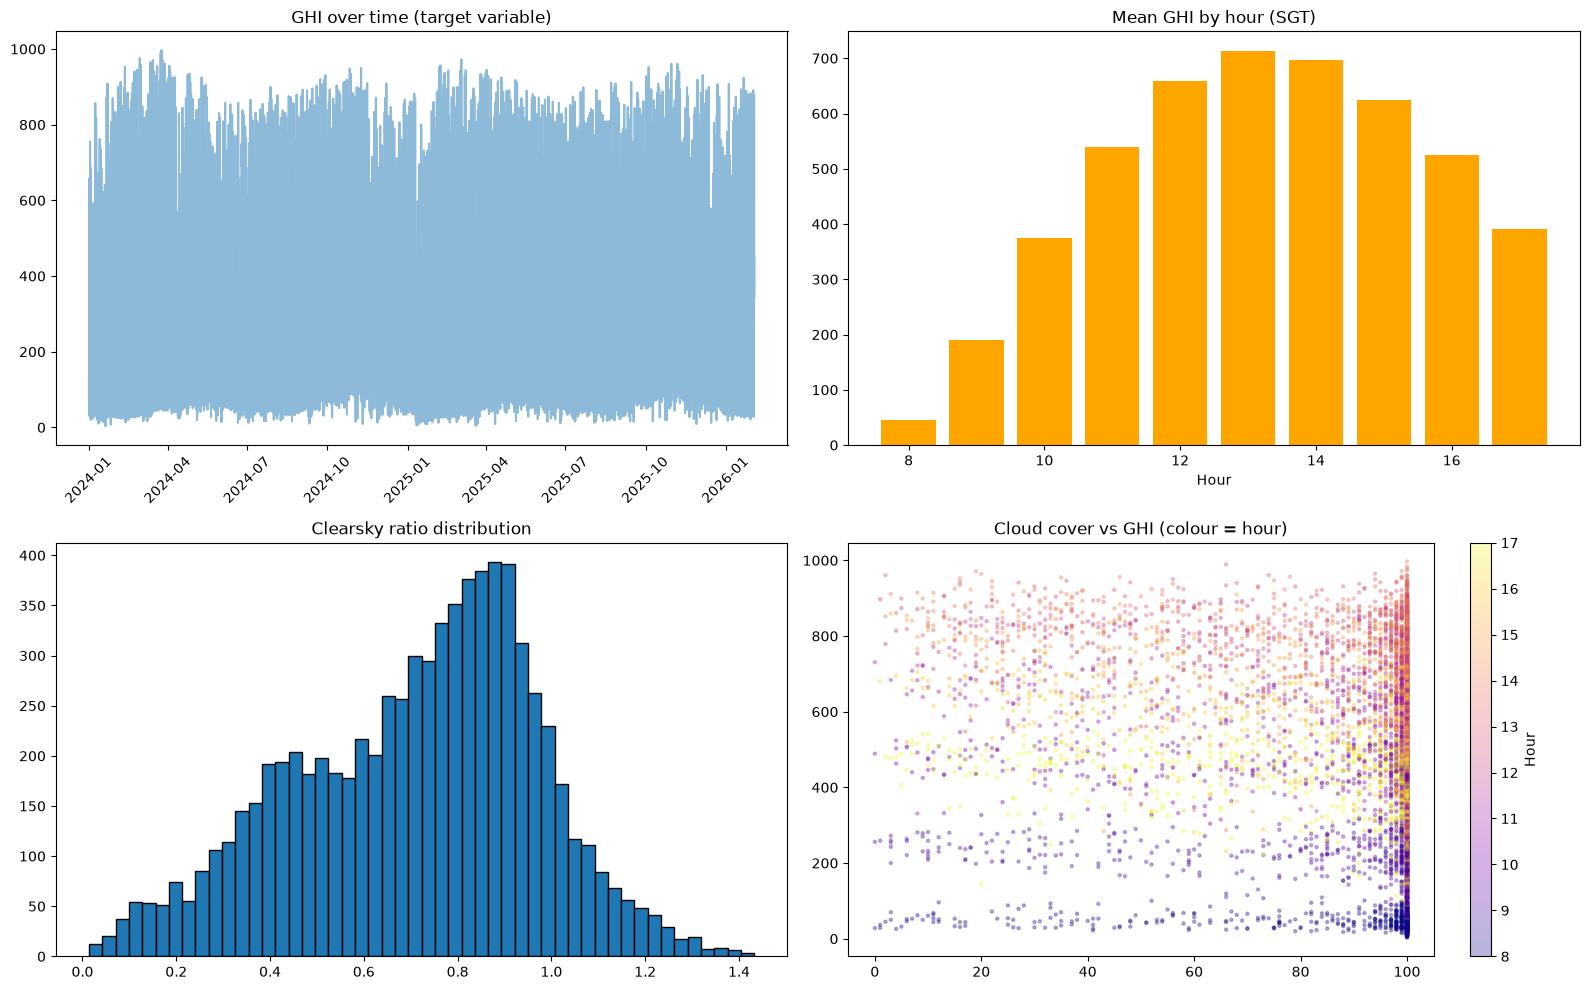


Correlation with GHI:
ghi                         1.000000
pv_actual                   0.999941
temperature_2m              0.864442
direct_normal_irradiance    0.819759
ghi_clearsky                0.807999
clearsky_ratio              0.766938
diffuse_radiation           0.524712
hour                        0.488120
wind_speed_10m              0.331613
sin_month                   0.021941
Name: ghi, dtype: float64


In [2]:
df = pd.read_csv(CSV_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# ── Remove leaky columns ──────────────────────────────────────────────────────
# pv_actual = 0.847 * ghi (r=0.9999) — drop as a feature, only keep for reference
# ghi will be used as TARGET (future values), not as an input feature for that step
LEAKY_COLS = ["pv_actual"]  # keep in df for reference but exclude from inputs

# ── Feature engineering ───────────────────────────────────────────────────────
df["clearsky_ratio"] = df["ghi"] / (df["ghi_clearsky"] + 1e-6)
df["hour"]           = df["timestamp"].dt.hour
df["month"]          = df["timestamp"].dt.month
df["sin_hour"]       = np.sin(2 * np.pi * df["hour"] / 24)
df["cos_hour"]       = np.cos(2 * np.pi * df["hour"] / 24)
df["sin_month"]      = np.sin(2 * np.pi * df["month"] / 12)
df["cos_month"]      = np.cos(2 * np.pi * df["month"] / 12)

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Total usable rows (image present): {df['image_path'].notna().sum()}")

# ── EDA ───────────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

axs[0,0].plot(df["timestamp"], df["ghi"], alpha=0.5)
axs[0,0].set_title("GHI over time (target variable)")
axs[0,0].tick_params(axis="x", rotation=45)

hourly = df.groupby("hour")["ghi"].mean()
axs[0,1].bar(hourly.index, hourly.values, color="orange")
axs[0,1].set_title("Mean GHI by hour (SGT)")
axs[0,1].set_xlabel("Hour")

axs[1,0].hist(df["clearsky_ratio"].clip(0, 1.5), bins=50, edgecolor="black")
axs[1,0].set_title("Clearsky ratio distribution")

sc = axs[1,1].scatter(df["cloud_cover"], df["ghi"], alpha=0.3, s=5, c=df["hour"], cmap="plasma")
plt.colorbar(sc, ax=axs[1,1], label="Hour")
axs[1,1].set_title("Cloud cover vs GHI (colour = hour)")

plt.tight_layout()
plt.savefig(f"{RESULTS}/plots/eda.png", dpi=150)
plt.show()

print("\nCorrelation with GHI:")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(df[num_cols].corr()["ghi"].sort_values(ascending=False).head(10))


## SECTION 2 — Baseline Model Honest

In [3]:
# ── Tabular features for baselines ───────────────────────────────────────────
# Only use features available at time t (no future GHI leaking in)
BASELINE_FEATURES = [
    "clearsky_ratio", "cloud_cover", "temperature_2m",
    "rain", "wind_speed_10m", "relative_humidity_2m",
    "sin_hour", "cos_hour", "sin_month", "cos_month",
    "ghi_clearsky",
    # lagged GHI (past values only — available at prediction time)
    "ghi_lag1", "ghi_lag2", "ghi_lag3",
]

df["ghi_lag1"] = df["ghi"].shift(1)
df["ghi_lag2"] = df["ghi"].shift(2)
df["ghi_lag3"] = df["ghi"].shift(3)

# Targets: GHI at t+1h, t+2h, t+3h
for h in [1, 2, 3]:
    df[f"ghi_t{h}h"] = df["ghi"].shift(-h)

# Drop rows with NaN (from lags or targets)
df_clean = df.dropna(subset=BASELINE_FEATURES + ["ghi_t1h","ghi_t2h","ghi_t3h"]).copy()
print(f"Clean rows for baseline: {len(df_clean)}")

# ── Train/val/test split (temporal — no shuffling) ────────────────────────────
n = len(df_clean)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_clean.iloc[:train_end].copy()
val_df   = df_clean.iloc[train_end:val_end].copy()
test_df  = df_clean.iloc[val_end:].copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

X_train = train_df[BASELINE_FEATURES].values
X_val   = val_df[BASELINE_FEATURES].values
X_test  = test_df[BASELINE_FEATURES].values

results = []
for h in [1, 2, 3]:
    y_train = train_df[f"ghi_t{h}h"].values
    y_test  = test_df[f"ghi_t{h}h"].values

    for name, model in [
        ("Linear Regression", LinearRegression()),
        ("Random Forest",     RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)),
        ("LightGBM",          lgb.LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)),
    ]:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        mae  = mean_absolute_error(y_test, pred)
        r2   = r2_score(y_test, pred)
        results.append({"Model": name, "Horizon": f"t+{h}h", "MAE_Wm2": mae, "R2": r2})
        print(f"{name:20s} t+{h}h → MAE={mae:.1f} W/m²  R²={r2:.4f}")

baseline_df = pd.DataFrame(results)
baseline_df.to_csv(f"{RESULTS}/baseline_ghi_comparison.csv", index=False)
print("\nBaselines saved ✓")


Clean rows for baseline: 7634
Train: 5343 | Val: 1145 | Test: 1146
Linear Regression    t+1h → MAE=81.1 W/m²  R²=0.8266
Random Forest        t+1h → MAE=63.5 W/m²  R²=0.8813
LightGBM             t+1h → MAE=63.3 W/m²  R²=0.8809
Linear Regression    t+2h → MAE=106.0 W/m²  R²=0.7190
Random Forest        t+2h → MAE=82.5 W/m²  R²=0.8078
LightGBM             t+2h → MAE=82.1 W/m²  R²=0.8131
Linear Regression    t+3h → MAE=121.6 W/m²  R²=0.6380
Random Forest        t+3h → MAE=90.0 W/m²  R²=0.7816
LightGBM             t+3h → MAE=89.8 W/m²  R²=0.7768

Baselines saved ✓


## SECTION 3 — Image Preprocessing (PNG → NPY)

In [4]:
# ── Convert existing .npy files to grayscale RGB (run once) ──────────────────
import os
import numpy as np

npy_dir = NPY_DIR
count = 0
already_gray = 0

for root, dirs, files in os.walk(npy_dir):
    for f in files:
        if f.endswith(".npy"):
            path = os.path.join(root, f)
            arr  = np.load(path)  # (224, 224, 3)
            if np.allclose(arr[:,:,0], arr[:,:,1], atol=1e-3):
                already_gray += 1
                continue
            gray     = arr.mean(axis=-1, keepdims=True)
            arr_gray = np.repeat(gray, 3, axis=-1)
            np.save(path, arr_gray)
            count += 1
            if count % 500 == 0:
                print(f"  Converted {count} files...")

print(f"Done — converted {count} | already grayscale: {already_gray}")

Done — converted 0 | already grayscale: 0


In [5]:
def save_images_as_npy(dataframe, npy_dir=NPY_DIR):
    paths = dataframe["image_path"].dropna().unique().tolist()
    total = len(paths)
    already = sum(
        1 for p in paths
        if os.path.exists(
            os.path.join(npy_dir,
                os.path.relpath(os.path.join(ROOT, p), SAT_DIR)).replace(".png", ".npy"))
    )
    if already == total:
        print(f"All {total} .npy files already exist — skipping.")
        return
    print(f"Saving {total - already} images as .npy (skipping {already} done)...")
    start = time.time()
    for i, path in enumerate(paths):
        rel      = os.path.relpath(os.path.join(ROOT, path), SAT_DIR)
        npy_path = os.path.join(npy_dir, rel).replace(".png", ".npy")
        os.makedirs(os.path.dirname(npy_path), exist_ok=True)
        if os.path.exists(npy_path):
            continue
        try:
            with Image.open(os.path.join(ROOT, path)) as img:
                # ── Convert to grayscale then back to RGB for JAXA consistency ──
                gray = img.convert("L").resize((224, 224), Image.BILINEAR)
                arr  = np.array(gray, dtype=np.float32) / 255.0  # (224, 224)
                arr  = np.stack([arr, arr, arr], axis=-1)         # (224, 224, 3)
            np.save(npy_path, arr)
        except Exception as e:
            print(f"  Failed [{i}]: {e}")
        if (i+1) % 500 == 0 or (i+1) == total:
            elapsed   = time.time() - start
            rate      = (i+1) / elapsed
            remaining = (total - i - 1) / rate if rate > 0 else 0
            print(f"  {i+1}/{total} | {elapsed/60:.1f}m | ~{remaining/60:.1f}m left | {rate:.0f} img/s")
    print("Done saving .npy files.")

save_images_as_npy(df_clean)

Saving 7625 images as .npy (skipping 0 done)...
  500/7625 | 0.3m | ~4.6m left | 26 img/s
  1000/7625 | 0.8m | ~5.1m left | 22 img/s
  1500/7625 | 1.1m | ~4.6m left | 22 img/s
  2000/7625 | 1.5m | ~4.2m left | 22 img/s
  2500/7625 | 2.0m | ~4.1m left | 21 img/s
  3000/7625 | 2.5m | ~3.8m left | 20 img/s
  3500/7625 | 3.0m | ~3.5m left | 20 img/s
  4000/7625 | 3.4m | ~3.1m left | 19 img/s
  4500/7625 | 3.9m | ~2.7m left | 19 img/s
  5000/7625 | 4.4m | ~2.3m left | 19 img/s
  5500/7625 | 4.9m | ~1.9m left | 19 img/s
  6000/7625 | 5.4m | ~1.5m left | 19 img/s
  6500/7625 | 6.0m | ~1.0m left | 18 img/s
  7000/7625 | 6.4m | ~0.6m left | 18 img/s
  7500/7625 | 6.9m | ~0.1m left | 18 img/s
  7625/7625 | 7.0m | ~0.0m left | 18 img/s
Done saving .npy files.


In [6]:
# Sanity check: satellite images are where the CSV says they are
sample = df_clean["image_path"].dropna().iloc[0]
print("Sample image_path from CSV:", sample)
print("Exists on disk:", os.path.exists(os.path.join(ROOT, sample)))

Sample image_path from CSV: data/satellite/2024/01/himawari_4d_20240101_030000.png
Exists on disk: True


## SECTION 3.5 — SwimSeg CNN Pretraining

Pretrain the EfficientNetB2 encoder on SwimSeg sky/cloud segmentation **before**
fusion-model training. This gives the CNN cloud-aware spatial features rather than
generic ImageNet features.

**Setup:** make sure the `swimseg/` folder is next to this notebook (on RunPod: `/workspace/swimseg/`). Skipped automatically if `swimseg_encoder.pt` already exists.

SwimSeg details:
- 1,013 Singapore sky images with binary cloud/sky masks (Oct 2013 – Jul 2015)
- Split by date (not random) to prevent session-level data leakage
- Saves `swimseg_encoder.pt` — backbone weights only — loaded by PhysicsGatedFusionModel

Skip this cell (set `SKIP_SWIMSEG = True`) if you already have `swimseg_encoder.pt`.

In [7]:
# ── SwimSeg pretraining config ───────────────────────────────────────────────
SWIMSEG_DIR    = f"swimseg"            # swimseg/ folder
SWIMSEG_ENC    = f"swimseg_encoder.pt"  # output: loaded by fusion model
SKIP_SWIMSEG   = os.path.exists(SWIMSEG_ENC)    # skip if already pretrained

print(f"SwimSeg dir exists : {os.path.exists(SWIMSEG_DIR)}")
print(f"Encoder exists     : {os.path.exists(SWIMSEG_ENC)}")
print(f"Will skip pretrain : {SKIP_SWIMSEG}")

SwimSeg dir exists : True
Encoder exists     : False
Will skip pretrain : False


In [10]:
# ── SwimSeg Dataset & FPN Decoder ────────────────────────────────────────────
# (only defines classes — no training yet)

from torch.utils.data import Dataset as _Dataset
import torch.nn.functional as F

class SwimSegDataset(_Dataset):
    """Sky/cloud segmentation dataset. Split by shooting date to avoid leakage."""
    def __init__(self, records, swimseg_dir, augment=False):
        self.records  = records.reset_index(drop=True)
        self.img_dir  = os.path.join(swimseg_dir, "images")
        self.gt_dir   = os.path.join(swimseg_dir, "GTmaps")
        self.augment  = augment
        self._mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        self._std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __len__(self):  return len(self.records)

    def __getitem__(self, idx):
        num   = int(self.records.iloc[idx]["Number"])
        fname = f"{num:04d}.png"

        img = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")
        img = img.resize((224, 224), Image.BILINEAR)
        img_t = torch.from_numpy(np.array(img, dtype=np.float32) / 255.0).permute(2,0,1)

        mask = Image.open(os.path.join(self.gt_dir, f"{num:04d}_GT.png")).convert("L")
        mask = mask.resize((224, 224), Image.NEAREST)
        mask_t = torch.from_numpy((np.array(mask) > 128).astype(np.float32))  # (H,W)

        if self.augment:
            if torch.rand(1) > 0.5:
                img_t  = torch.flip(img_t,  [2]); mask_t = torch.flip(mask_t, [1])
            if torch.rand(1) > 0.5:
                img_t  = torch.flip(img_t,  [1]); mask_t = torch.flip(mask_t, [0])
            if torch.rand(1) > 0.5:
                b = 1.0 + (torch.rand(1).item()-0.5)*0.4
                img_t = torch.clamp(img_t * b, 0, 1)
            if torch.rand(1) > 0.5:
                c = 1.0 + (torch.rand(1).item()-0.5)*0.4
                m = img_t.mean(dim=[1,2], keepdim=True)
                img_t = torch.clamp(m + c*(img_t - m), 0, 1)

        img_t = (img_t - self._mean) / self._std
        return img_t, mask_t.unsqueeze(0), mask_t.mean()  # img, mask, cloud_ratio


class _FPNDecoder(nn.Module):
    STAGE_CH = [16, 24, 48, 120, 352]; H = 128
    def __init__(self):
        super().__init__()
        self.laterals = nn.ModuleList([nn.Conv2d(c, self.H, 1) for c in self.STAGE_CH])
        self.smooths  = nn.ModuleList([
            nn.Sequential(nn.Conv2d(self.H, self.H, 3, padding=1, bias=False),
                          nn.BatchNorm2d(self.H), nn.ReLU(inplace=True))
            for _ in self.STAGE_CH])
        self.head = nn.Sequential(
            nn.Conv2d(self.H, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Conv2d(64, 1, 1))
        self.aux_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(352, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())

    def forward(self, feats):
        x = self.laterals[4](feats[4])
        for i in range(3, -1, -1):
            x = F.interpolate(x, size=feats[i].shape[-2:], mode="nearest")
            x = self.smooths[i](x + self.laterals[i](feats[i]))
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        return self.head(x), self.aux_head(feats[4])


class SwimSegModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = timm.create_model("efficientnet_b2", pretrained=True, features_only=True)
        self.decoder = _FPNDecoder()
    def forward(self, x):
        return self.decoder(self.encoder(x))


def _dice_bce(logits, masks):
    bce  = nn.functional.binary_cross_entropy_with_logits(logits, masks)
    p    = torch.sigmoid(logits).view(logits.shape[0], -1)
    t    = masks.view(masks.shape[0], -1)
    dice = 1 - (2*(p*t).sum(1)+1) / (p.sum(1)+t.sum(1)+1)
    return 0.5*bce + 0.5*dice.mean()


def _iou(logits, masks):
    p = (torch.sigmoid(logits) > 0.5).float().view(logits.shape[0], -1)
    t = masks.view(masks.shape[0], -1)
    return ((p*t).sum(1) / (p+t-p*t).sum(1).clamp(min=1e-6)).mean().item()


print("SwimSeg classes defined ✓")

SwimSeg classes defined ✓


In [11]:
# ── Run SwimSeg pretraining ───────────────────────────────────────────────────
if SKIP_SWIMSEG:
    print(f"Skipping — encoder already exists at {SWIMSEG_ENC}")
else:
    import pandas as _pd
    meta   = _pd.read_csv(os.path.join(SWIMSEG_DIR, "metadata.csv"))
    dates  = sorted(meta["Date"].unique())
    n_val  = max(1, int(len(dates) * 0.2))
    val_dates   = set(dates[-n_val:])
    train_dates = set(dates[:-n_val])
    tr_meta = meta[meta["Date"].isin(train_dates)]
    va_meta = meta[meta["Date"].isin(val_dates)]
    print(f"  Train: {len(tr_meta)} images ({len(train_dates)} dates) | "
          f"Val: {len(va_meta)} images ({len(val_dates)} dates)")

    from torch.utils.data import DataLoader as _DL
    tr_dl = _DL(SwimSegDataset(tr_meta, SWIMSEG_DIR, augment=True),
                batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
    va_dl = _DL(SwimSegDataset(va_meta, SWIMSEG_DIR, augment=False),
                batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

    sw_model = SwimSegModel().to(device)
    sw_opt   = torch.optim.AdamW(sw_model.parameters(), lr=3e-4, weight_decay=1e-4)
    sw_sched = torch.optim.lr_scheduler.CosineAnnealingLR(sw_opt, T_max=50)
    aux_loss = nn.MSELoss()
    best_iou = 0.0

    print(f"\n{'Ep':>4}  {'Tr Loss':>9}  {'Va Loss':>9}  {'Va IoU':>8}")
    print("-" * 40)

    for ep in range(1, 51):
        sw_model.train()
        tr_losses = []
        for imgs, masks, ratios in tr_dl:
            imgs  = imgs.to(device);  masks = masks.to(device)
            ratios = ratios.float().unsqueeze(1).to(device)
            logits, pred_ratio = sw_model(imgs)
            loss = _dice_bce(logits, masks) + 0.2 * aux_loss(pred_ratio, ratios)
            sw_opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(sw_model.parameters(), 1.0)
            sw_opt.step(); tr_losses.append(loss.item())
        sw_sched.step()

        sw_model.eval()
        va_losses, va_ious = [], []
        with torch.no_grad():
            for imgs, masks, ratios in va_dl:
                imgs  = imgs.to(device); masks = masks.to(device)
                ratios = ratios.float().unsqueeze(1).to(device)
                logits, pred_ratio = sw_model(imgs)
                va_losses.append((_dice_bce(logits, masks) + 0.2*aux_loss(pred_ratio, ratios)).item())
                va_ious.append(_iou(logits, masks))

        va_iou = float(np.mean(va_ious))
        print(f"{ep:>4}  {np.mean(tr_losses):>9.4f}  {np.mean(va_losses):>9.4f}  {va_iou:>8.4f}"
              + ("  ✓ saved" if va_iou > best_iou else ""))
        if va_iou > best_iou:
            best_iou = va_iou
            torch.save(sw_model.encoder.state_dict(), SWIMSEG_ENC)

    del sw_model
    torch.cuda.empty_cache()
    print(f"\nPretraining done. Best IoU: {best_iou:.4f} → {SWIMSEG_ENC}")

  Train: 817 images (14 dates) | Val: 196 images (3 dates)


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.



  Ep    Tr Loss    Va Loss    Va IoU
----------------------------------------
   1     0.3182     0.2481    0.8303  ✓ saved
   2     0.2498     0.2650    0.8098
   3     0.2149     0.2264    0.8199
   4     0.1973     0.2109    0.8416  ✓ saved
   5     0.1743     0.1907    0.8526  ✓ saved
   6     0.1578     0.1858    0.8483
   7     0.1503     0.1608    0.8619  ✓ saved
   8     0.1471     0.1565    0.8624  ✓ saved
   9     0.1363     0.1805    0.8431
  10     0.1288     0.1747    0.8499
  11     0.1182     0.1489    0.8699  ✓ saved
  12     0.1126     0.1596    0.8562
  13     0.1072     0.1575    0.8639
  14     0.1020     0.1596    0.8612
  15     0.0991     0.1421    0.8742  ✓ saved
  16     0.0965     0.1582    0.8640
  17     0.0964     0.1455    0.8751  ✓ saved
  18     0.0947     0.1617    0.8595
  19     0.0898     0.1570    0.8679
  20     0.0868     0.1407    0.8781  ✓ saved
  21     0.0852     0.1634    0.8593
  22     0.0833     0.1432    0.8780
  23     0.0842     0.1636

## SECTION 4 — Load Images into RAM

In [12]:
print("Loading all images into RAM...")
npy_cache = {}
paths = df_clean["image_path"].dropna().unique().tolist()
start = time.time()

for i, path in enumerate(paths):
    rel      = os.path.relpath(os.path.join(ROOT, path), SAT_DIR)
    npy_path = os.path.join(NPY_DIR, rel).replace(".png", ".npy")
    if os.path.exists(npy_path):
        try:
            arr = np.load(npy_path)                          # (224,224,3) 0-1
            arr = (arr - IMG_MEAN) / IMG_STD                 # normalize
            npy_cache[path] = torch.from_numpy(
                arr.transpose(2, 0, 1)).float()              # (3,224,224)
        except Exception:
            npy_cache[path] = None
    else:
        npy_cache[path] = None
    if (i+1) % 1000 == 0 or (i+1) == len(paths):
        print(f"  {i+1}/{len(paths)} | {(time.time()-start)/60:.1f}m elapsed")

ram = psutil.virtual_memory()
print(f"\nDone. {len(npy_cache)} images in RAM.")
print(f"RAM: {ram.used/1e9:.1f} GB used / {ram.total/1e9:.1f} GB total")


Loading all images into RAM...
  1000/7625 | 0.1m elapsed
  2000/7625 | 0.3m elapsed
  3000/7625 | 0.4m elapsed
  4000/7625 | 0.5m elapsed
  5000/7625 | 0.6m elapsed
  6000/7625 | 0.7m elapsed
  7000/7625 | 0.8m elapsed
  7625/7625 | 0.9m elapsed

Done. 7625 images in RAM.
RAM: 75.0 GB used / 1081.9 GB total


In [13]:
# ── Optical flow precomputation (cloud motion vectors) ────────────────────────
# Computes mean flow in the Singapore RoI (center of image) between consecutive
# hourly frames.  Gives the physics gate an explicit cloud-advection prior.
import cv2

FLOW_SIZE   = 64          # downsample before computing flow (speed vs accuracy)
FLOW_CENTER = slice(16, 48)  # centre 32px of 64px — Singapore RoI at FLOW_SIZE

print("Precomputing optical flow between consecutive frames...")
flow_cache = {}
all_paths  = df_clean["image_path"].values   # ordered by timestamp

def _to_gray64(tensor):
    """Denormalize channel-0, resize to 64×64, return uint8 array."""
    arr = tensor[0].numpy()
    arr = np.clip(arr * 0.229 + 0.485, 0, 1)
    arr = (arr * 255).astype(np.uint8)
    return cv2.resize(arr, (FLOW_SIZE, FLOW_SIZE), interpolation=cv2.INTER_LINEAR)

start = time.time()
n_computed = 0
for i in range(len(all_paths)):
    path_curr = all_paths[i]
    if not isinstance(path_curr, str) or path_curr not in npy_cache or npy_cache[path_curr] is None:
        if isinstance(path_curr, str):
            flow_cache[path_curr] = torch.zeros(2)
        continue

    path_prev = all_paths[i-1] if i > 0 else None
    frame_curr = npy_cache[path_curr]

    if (path_prev and isinstance(path_prev, str)
            and path_prev in npy_cache and npy_cache[path_prev] is not None):
        g_prev = _to_gray64(npy_cache[path_prev])
        g_curr = _to_gray64(frame_curr)
        flow = cv2.calcOpticalFlowFarneback(
            g_prev, g_curr, None,
            pyr_scale=0.5, levels=3, winsize=11,
            iterations=3, poly_n=5, poly_sigma=1.1, flags=0
        )  # (64, 64, 2)
        # Average over centre region (Singapore)
        vx = float(flow[FLOW_CENTER, FLOW_CENTER, 0].mean()) / FLOW_SIZE
        vy = float(flow[FLOW_CENTER, FLOW_CENTER, 1].mean()) / FLOW_SIZE
    else:
        vx, vy = 0.0, 0.0

    flow_cache[path_curr] = torch.tensor([vx, vy], dtype=torch.float32)
    n_computed += 1

print(f"Flow computed for {n_computed:,} frames in {time.time()-start:.1f}s")
print(f"Sample flow: vx={list(flow_cache.values())[100][0]:.4f}  vy={list(flow_cache.values())[100][1]:.4f}")


Precomputing optical flow between consecutive frames...
Flow computed for 7,629 frames in 10.0s
Sample flow: vx=-0.0042  vy=0.0022


## SECTION 5 — Dataset & DataLoaders

**Target: GHI at t+1h, t+2h, t+3h**

**Inputs (no leakage):**
- Past 24h window of: `clearsky_ratio`, `cloud_cover`, `temperature_2m`, `rain`, `wind_speed_10m`, `relative_humidity_2m`, `sin_hour`, `cos_hour`, `sin_month`, `cos_month`, `ghi_lag1` (i.e. past GHI)
- Satellite image at time t
- Future `ghi_clearsky` (pure solar geometry — always known ahead of time)
- Gate features: clearsky_ratio, cloud_cover

In [14]:
import torch.nn.functional as F   # needed for RoI interpolation

# ── Tabular columns come from model.py — guaranteed to match inference ────────
from model import TABULAR_COLS
ZEROS_IMG = torch.zeros((3, 224, 224), dtype=torch.float32)

class GHIForecastDataset(Dataset):
    """
    Returns per-sample:
      multi_frame  (9,224,224)  — frames at t, t-1h, t-2h stacked channel-wise
      roi_image    (3,224,224)  — centre-crop of frame_t (2°×2° over Singapore)
      tabular_seq  (24,11)      — normalised weather lookback
      future_clearsky (3,)      — known clearsky GHI for t+1..t+3
      targets      (3,)         — normalised GHI at t+1..t+3
      gate_features (4,)        — [clearsky_ratio, cloud_cover, flow_vx, flow_vy]
    """
    def __init__(self, dataframe, window_size=24, is_train=True, train_stats=None):
        self.window_size = window_size
        df_r = dataframe.reset_index(drop=True)

        self.tab_arr    = df_r[TABULAR_COLS].values.astype(np.float32)
        self.ghi_cs_arr = df_r["ghi_clearsky"].values.astype(np.float32)
        self.ghi_arr    = df_r["ghi"].values.astype(np.float32)
        self.img_paths  = df_r["image_path"].values
        self.cr_arr     = df_r["clearsky_ratio"].values.astype(np.float32)
        self.cc_arr     = df_r["cloud_cover"].values.astype(np.float32)
        self.df         = df_r

        if is_train:
            self.mean = self.tab_arr.mean(axis=0)
            self.std  = self.tab_arr.std(axis=0) + 1e-6
        else:
            self.mean = train_stats["mean"]
            self.std  = train_stats["std"]
        self.tab_arr = (self.tab_arr - self.mean) / self.std

        if is_train:
            self.ghi_mean = float(self.ghi_arr.mean())
            self.ghi_std  = float(self.ghi_arr.std()) + 1e-6
        else:
            self.ghi_mean = train_stats["ghi_mean"]
            self.ghi_std  = train_stats["ghi_std"]

        self.valid_indices = [
            i for i in range(window_size - 1, len(df_r) - 3)
            if df_r["image_path"].iloc[i] and pd.notna(df_r["image_path"].iloc[i])
        ]

    def _get_frame(self, idx):
        """Return (3,224,224) tensor for dataframe row idx, or zeros."""
        if idx < 0:
            return ZEROS_IMG
        path = self.img_paths[idx]
        if not isinstance(path, str) or pd.isna(path):
            return ZEROS_IMG
        frame = npy_cache.get(path)
        return frame if frame is not None else ZEROS_IMG

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        t = self.valid_indices[idx]

        # ── Tabular sequence ──────────────────────────────────────────────────
        tabular_seq     = torch.from_numpy(self.tab_arr[t - self.window_size + 1 : t + 1])
        future_clearsky = torch.from_numpy(self.ghi_cs_arr[t+1 : t+4])

        raw_targets = self.ghi_arr[t+1 : t+4]
        targets     = torch.tensor(
            (raw_targets - self.ghi_mean) / self.ghi_std, dtype=torch.float32)

        # ── Three consecutive satellite frames ────────────────────────────────
        frame_t  = self._get_frame(t)
        frame_t1 = self._get_frame(t - 1)
        frame_t2 = self._get_frame(t - 2)
        multi_frame = torch.cat([frame_t, frame_t1, frame_t2], dim=0)  # (9,224,224)

        # ── RoI: centre 50% crop of current frame, upscaled back to 224×224 ──
        # Corresponds to the inner ~2°×2° around Singapore (assuming 4° total crop)
        roi = frame_t[:, 56:168, 56:168]                                # (3,112,112)
        roi = F.interpolate(roi.unsqueeze(0), size=(224, 224),
                            mode="bilinear", align_corners=False).squeeze(0)  # (3,224,224)

        # ── Optical flow gate features ────────────────────────────────────────
        img_path = self.img_paths[t]
        flow = flow_cache.get(img_path, torch.zeros(2))

        gate_features = torch.tensor([
            float(self.cr_arr[t]),
            float(self.cc_arr[t]) / 100.0,
            float(flow[0]),    # vx — east-west cloud motion
            float(flow[1]),    # vy — north-south cloud motion
        ], dtype=torch.float32)

        return {
            "tabular_seq":     tabular_seq,       # (24,11)
            "multi_frame":     multi_frame,        # (9,224,224)
            "roi_image":       roi,                # (3,224,224)
            "future_clearsky": future_clearsky,    # (3,)
            "targets":         targets,            # (3,)
            "gate_features":   gate_features,      # (4,)
            "idx":             t,
        }

# ── Build splits ──────────────────────────────────────────────────────────────
n      = len(df_clean)
t_end  = int(n * 0.70)
v_end  = int(n * 0.85)

tr_df  = df_clean.iloc[:t_end].copy()
va_df  = df_clean.iloc[t_end:v_end].copy()
te_df  = df_clean.iloc[v_end:].copy()

train_dataset = GHIForecastDataset(tr_df, is_train=True)
train_stats   = {
    "mean":     train_dataset.mean,
    "std":      train_dataset.std,
    "ghi_mean": train_dataset.ghi_mean,
    "ghi_std":  train_dataset.ghi_std,
}
val_dataset   = GHIForecastDataset(va_df, is_train=False, train_stats=train_stats)
test_dataset  = GHIForecastDataset(te_df, is_train=False, train_stats=train_stats)

BATCH_SIZE = 128 if torch.cuda.is_available() else 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"GHI mean: {train_stats['ghi_mean']:.1f} W/m²  std: {train_stats['ghi_std']:.1f} W/m²")

# Sanity check one batch
_b = next(iter(train_loader))
print(f"multi_frame : {_b['multi_frame'].shape}")
print(f"roi_image   : {_b['roi_image'].shape}")
print(f"gate_features: {_b['gate_features'].shape}  (clearsky, cloud, vx, vy)")


Train: 5312 | Val: 1119 | Test: 1120
Train batches: 42 | Val: 9 | Test: 9
GHI mean: 475.0 W/m²  std: 259.6 W/m²
multi_frame : torch.Size([128, 9, 224, 224])
roi_image   : torch.Size([128, 3, 224, 224])
gate_features: torch.Size([128, 4])  (clearsky, cloud, vx, vy)


## SECTION 6 — Model Architecture (imported from `model.py`)

The model classes live in **`model.py`** — the same file `predict.py` and
`verify.py` use for inference. This guarantees any checkpoint trained here
loads for prediction with zero architecture drift.

- `PhysicsGatedFusionModelV2` — dual EfficientNetB2 branches (global multi-frame
  + Singapore RoI), 8-head cross-attention over 196 patches, 4-input physics
  gate (clearsky ratio, cloud cover, optical-flow vx/vy)
- Ablations via `ablation=` argument: `"lstm"`, `"cnn"`, `"concat"`

In [15]:
from model import PhysicsGatedFusionModelV2 as PhysicsGatedFusionModel

print("Model imported from model.py ✓")
print("  Cross-attention: 8-head, 196 patches (3 global frames × 49 + 1 RoI × 49)")
print("  Physics gate   : 4 inputs (clearsky_ratio, cloud_cover, vx, vy)")

Model imported from model.py ✓
  Cross-attention: 8-head, 196 patches (3 global frames × 49 + 1 RoI × 49)
  Physics gate   : 4 inputs (clearsky_ratio, cloud_cover, vx, vy)


## SECTION 7 — Training

In [16]:
def gaussian_nll_loss(mu, sigma, target):
    return torch.mean(torch.sum(torch.log(sigma) + (target - mu)**2 / (2 * sigma**2), dim=1))

def train_model(model, train_loader, val_loader, epochs=150, patience=20,
                ckpt="best_model.pt", lr=3e-5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=8, verbose=True)

    scaler     = torch.cuda.amp.GradScaler() if USE_AMP else None
    best_val, pat_cnt = float("inf"), 0
    history    = {k: [] for k in ["train_nll","val_nll","train_mae","val_mae"]}
    model.to(device)
    ghi_std = train_stats["ghi_std"]

    print(f"\n{'Ep':>4} | {'Tr NLL':>9} {'Tr MAE':>9} | {'Va NLL':>9} {'Va MAE':>9} | {'Status':<16} {'Time':>6}")
    print("-" * 80)
    start_total = time.time()

    for epoch in range(epochs):
        ep_start = time.time()

        # Unfreeze CNN at epoch 20 when SwimSeg pretrained (stable initialisation)
        if epoch == 20 and _enc_path and hasattr(model, "unfreeze_cnn"):
            model.unfreeze_cnn()
            for pg in optimizer.param_groups:
                pg["lr"] = lr / 10
            print("  ★ CNN unfrozen at epoch 20 with lr/10 (SwimSeg pretrained)")

        # ── Train ──────────────────────────────────────────────────────────────
        model.train()
        tr_loss = tr_mae = n_batches = 0

        for batch in train_loader:
            tab = batch["tabular_seq"].to(device)
            mf  = batch["multi_frame"].to(device)
            roi = batch["roi_image"].to(device)
            fc  = batch["future_clearsky"].to(device)
            tgt = batch["targets"].to(device)
            gf  = batch["gate_features"].to(device)

            optimizer.zero_grad(set_to_none=True)

            if USE_AMP:
                with torch.cuda.amp.autocast():
                    mu, sigma = model(tab, mf, roi, fc, gf)
                    loss = gaussian_nll_loss(mu, sigma, tgt)
                if torch.isnan(loss) or torch.isinf(loss):
                    continue
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            else:
                mu, sigma = model(tab, mf, roi, fc, gf)
                loss = gaussian_nll_loss(mu, sigma, tgt)
                if torch.isnan(loss) or torch.isinf(loss):
                    continue
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            tr_loss  += loss.item() * tgt.size(0)
            tr_mae   += torch.abs(mu[:, 0] - tgt[:, 0]).sum().item()
            n_batches += 1

        if n_batches == 0:
            print(f"  ⚠️  Epoch {epoch+1} skipped — all NaN"); continue

        # ── Validate ───────────────────────────────────────────────────────────
        model.eval()
        va_loss = va_mae = 0.0
        with torch.no_grad():
            for batch in val_loader:
                tab = batch["tabular_seq"].to(device)
                mf  = batch["multi_frame"].to(device)
                roi = batch["roi_image"].to(device)
                fc  = batch["future_clearsky"].to(device)
                tgt = batch["targets"].to(device)
                gf  = batch["gate_features"].to(device)
                if USE_AMP:
                    with torch.cuda.amp.autocast():
                        mu, sigma = model(tab, mf, roi, fc, gf)
                        loss = gaussian_nll_loss(mu, sigma, tgt)
                else:
                    mu, sigma = model(tab, mf, roi, fc, gf)
                    loss = gaussian_nll_loss(mu, sigma, tgt)
                if torch.isnan(loss) or torch.isinf(loss): continue
                va_loss += loss.item() * tgt.size(0)
                va_mae  += torch.abs(mu[:, 0] - tgt[:, 0]).sum().item()

        ntr = len(train_loader.dataset); nva = len(val_loader.dataset)
        tr_loss /= ntr; va_loss /= nva
        tr_mae  /= ntr; va_mae  /= nva
        tr_mae_wm2 = tr_mae * ghi_std; va_mae_wm2 = va_mae * ghi_std

        history["train_nll"].append(tr_loss); history["val_nll"].append(va_loss)
        history["train_mae"].append(tr_mae_wm2); history["val_mae"].append(va_mae_wm2)
        scheduler.step(va_loss)

        ep_time = time.time() - ep_start
        remain  = ep_time * (epochs - epoch - 1)
        if va_loss < best_val:
            best_val, pat_cnt = va_loss, 0
            torch.save(model.state_dict(), ckpt); status = "✓ saved"
        else:
            pat_cnt += 1; status = f"patience {pat_cnt}/{patience}"

        print(f"{epoch+1:>4} | {tr_loss:>9.3f} {tr_mae_wm2:>7.1f}W/m² | "
              f"{va_loss:>9.3f} {va_mae_wm2:>7.1f}W/m² | {status:<16} "
              f"{ep_time:>5.0f}s (~{remain/60:.0f}m)")
        if pat_cnt >= patience:
            print(f"  Early stop at epoch {epoch+1}"); break

    total = time.time() - start_total
    print(f"\n✅ Done. Best val NLL: {best_val:.4f} → {ckpt} (total: {total/60:.1f}min)")
    return history

# ── Build full model ──────────────────────────────────────────────────────────
_enc_path = SWIMSEG_ENC if os.path.exists(SWIMSEG_ENC) else None
if _enc_path:
    print(f"✅ Using SwimSeg pretrained encoder: {_enc_path}")
else:
    print("ℹ️  No SwimSeg encoder found — using ImageNet weights")

model_full = PhysicsGatedFusionModel(
    ablation=None, pretrained_encoder_path=_enc_path,
    imagenet_init=(_enc_path is None),   # ImageNet warm start if no SwimSeg
).to(device)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print("✅ CUDA optimisations enabled")

total_p     = sum(p.numel() for p in model_full.parameters())
trainable_p = sum(p.numel() for p in model_full.parameters() if p.requires_grad)
print(f"Parameters : {total_p:,}")
print(f"Trainable  : {trainable_p:,}  (CNN frozen until epoch 20)")

history = train_model(
    model_full, train_loader, val_loader,
    epochs=150, patience=20,
    ckpt=f"{ROOT}/best_model.pt",
    lr=3e-5
)


✅ Using SwimSeg pretrained encoder: swimseg_encoder.pt
  ✓ SwimSeg encoder loaded (0 missing, 0 unexpected)
  ✓ SwimSeg encoder loaded (0 missing, 0 unexpected)
✅ CUDA optimisations enabled
Parameters : 15,505,804
Trainable  : 1,100,680  (CNN frozen until epoch 20)

  Ep |    Tr NLL    Tr MAE |    Va NLL    Va MAE | Status             Time
--------------------------------------------------------------------------------
   1 |     1.904   223.1W/m² |     1.204   201.3W/m² | ✓ saved             17s (~43m)
   2 |     1.296   201.1W/m² |     0.898   168.6W/m² | ✓ saved             11s (~27m)
   3 |     1.039   177.9W/m² |     0.537   133.8W/m² | ✓ saved             11s (~26m)
   4 |     0.699   147.9W/m² |     0.138   113.7W/m² | ✓ saved             11s (~26m)
   5 |     0.407   135.4W/m² |    -0.053   109.1W/m² | ✓ saved             11s (~26m)
   6 |     0.225   128.9W/m² |    -0.187   105.6W/m² | ✓ saved             11s (~26m)
   7 |     0.059   124.2W/m² |    -0.300   105.4W/m² | ✓ save

## SECTION 8 — Evaluate

In [17]:
def evaluate_model(model, loader, name, ckpt):
    model.load_state_dict(torch.load(ckpt, weights_only=True, map_location=device))
    model.eval(); model.to(device)

    ghi_mean = train_stats["ghi_mean"]
    ghi_std  = train_stats["ghi_std"]

    all_mu, all_sig, all_tgt = [], [], []
    with torch.no_grad():
        for batch in loader:
            tab = batch["tabular_seq"].to(device)
            mf  = batch["multi_frame"].to(device)
            roi = batch["roi_image"].to(device)
            fc  = batch["future_clearsky"].to(device)
            tgt = batch["targets"].to(device)
            gf  = batch["gate_features"].to(device)
            if USE_AMP:
                with torch.cuda.amp.autocast():
                    mu, sig = model(tab, mf, roi, fc, gf)
            else:
                mu, sig = model(tab, mf, roi, fc, gf)
            all_mu.append(mu.cpu()); all_sig.append(sig.cpu()); all_tgt.append(tgt.cpu())

    mu  = torch.cat(all_mu).numpy()
    sig = torch.cat(all_sig).numpy()
    tgt = torch.cat(all_tgt).numpy()

    mu_real  = mu  * ghi_std + ghi_mean
    sig_real = sig * ghi_std
    tgt_real = tgt * ghi_std + ghi_mean

    horizon_rows = []
    for h in range(3):
        lo   = mu_real[:,h] - 1.645*sig_real[:,h]
        hi   = mu_real[:,h] + 1.645*sig_real[:,h]
        picp = ((tgt_real[:,h]>=lo)&(tgt_real[:,h]<=hi)).mean()*100
        mae  = mean_absolute_error(tgt_real[:,h], mu_real[:,h])
        horizon_rows.append({
            "Horizon": f"t+{h+1}h",
            "MAE_Wm2":  mae,
            "RMSE_Wm2": np.sqrt(mean_squared_error(tgt_real[:,h], mu_real[:,h])),
            "R2":        r2_score(tgt_real[:,h], mu_real[:,h]),
            "nMAE_pct":  mae / train_stats["ghi_mean"] * 100,
            "PICP_pct":  picp
        })

    mae_a = mean_absolute_error(tgt_real, mu_real)
    glob  = {
        "Model":    name,
        "MAE_Wm2":  mae_a,
        "RMSE_Wm2": np.sqrt(mean_squared_error(tgt_real, mu_real)),
        "R2":        r2_score(tgt_real, mu_real),
        "nMAE_pct":  mae_a / train_stats["ghi_mean"] * 100,
        "PICP_pct":  ((tgt_real >= mu_real-1.645*sig_real) &
                      (tgt_real <= mu_real+1.645*sig_real)).mean()*100
    }
    return glob, horizon_rows, mu_real, sig_real, tgt_real

# ── Ablation study ────────────────────────────────────────────────────────────
final_results = []; eval_horizons = {}; pred_cache = {}

for ab_name, ab_type, ckpt in [
    ("LSTM-only",           "lstm",   f"{ROOT}/best_model_lstm.pt"),
    ("CNN-only",            "cnn",    f"{ROOT}/best_model_cnn.pt"),
    ("Naive concat fusion", "concat", f"{ROOT}/best_model_concat.pt"),
]:
    print(f"\nTraining ablation: {ab_name}")
    m = PhysicsGatedFusionModel(ablation=ab_type, pretrained_encoder_path=_enc_path,
                                imagenet_init=(_enc_path is None)).to(device)
    train_model(m, train_loader, val_loader, epochs=150, patience=15, ckpt=ckpt, lr=3e-5)
    g, hr, mu, sig, tgt = evaluate_model(m, test_loader, ab_name, ckpt)
    final_results.append(g); eval_horizons[ab_name] = hr
    pred_cache[ab_type] = (mu, sig, tgt)

print("\n--- Evaluating full fusion model ---")
g, hr, mu, sig, tgt = evaluate_model(
    model_full, test_loader, "Physics-Gated Fusion ★", f"{ROOT}/best_model.pt")
final_results.append(g)
eval_horizons["Physics-Gated Fusion ★"] = hr
pred_cache["full"] = (mu, sig, tgt)

final_df = pd.DataFrame(final_results)
final_df.to_csv(f"{RESULTS}/fusion_ghi_comparison.csv", index=False)
print("\n" + "="*70)
print(final_df.to_string(index=False))



Training ablation: LSTM-only
  ✓ SwimSeg encoder loaded (0 missing, 0 unexpected)
  ✓ SwimSeg encoder loaded (0 missing, 0 unexpected)

  Ep |    Tr NLL    Tr MAE |    Va NLL    Va MAE | Status             Time
--------------------------------------------------------------------------------
   1 |     1.747   214.3W/m² |     1.073   186.7W/m² | ✓ saved             13s (~31m)
   2 |     1.151   185.5W/m² |     0.702   144.7W/m² | ✓ saved             12s (~29m)
   3 |     0.876   161.1W/m² |     0.294   114.3W/m² | ✓ saved             12s (~30m)
   4 |     0.625   142.9W/m² |     0.003    99.7W/m² | ✓ saved             11s (~27m)
   5 |     0.434   132.2W/m² |    -0.150   103.3W/m² | ✓ saved             11s (~27m)
   6 |     0.264   127.1W/m² |    -0.264   102.0W/m² | ✓ saved             11s (~27m)
   7 |     0.107   122.8W/m² |    -0.380   101.6W/m² | ✓ saved             11s (~26m)
   8 |     0.001   122.3W/m² |    -0.434   102.3W/m² | ✓ saved             13s (~30m)
   9 |    -0.108   

## SECTION 9 — Visualixation

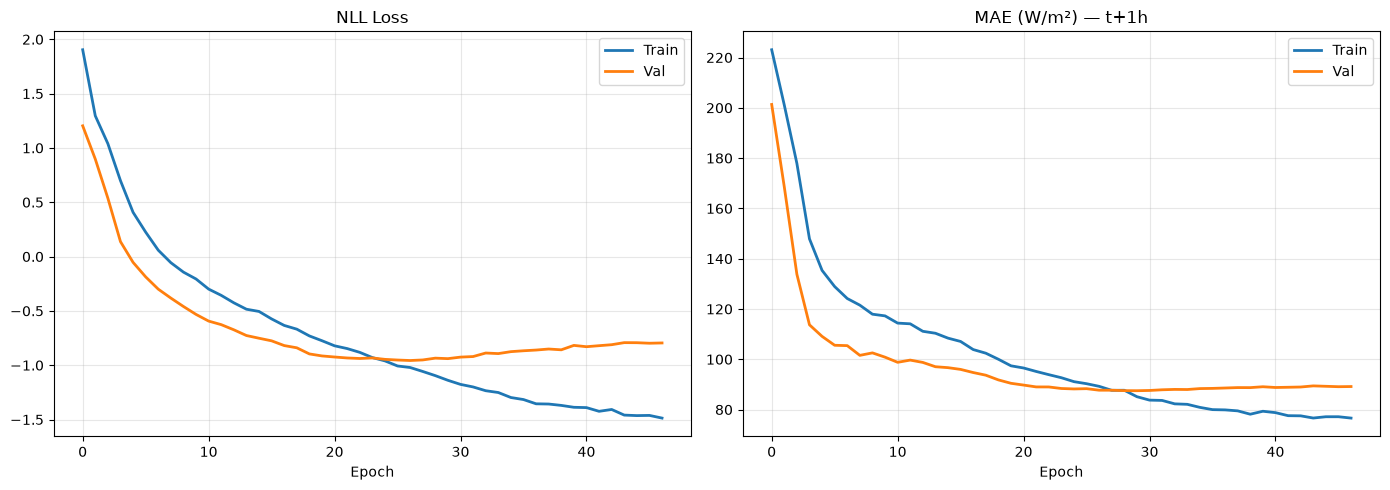

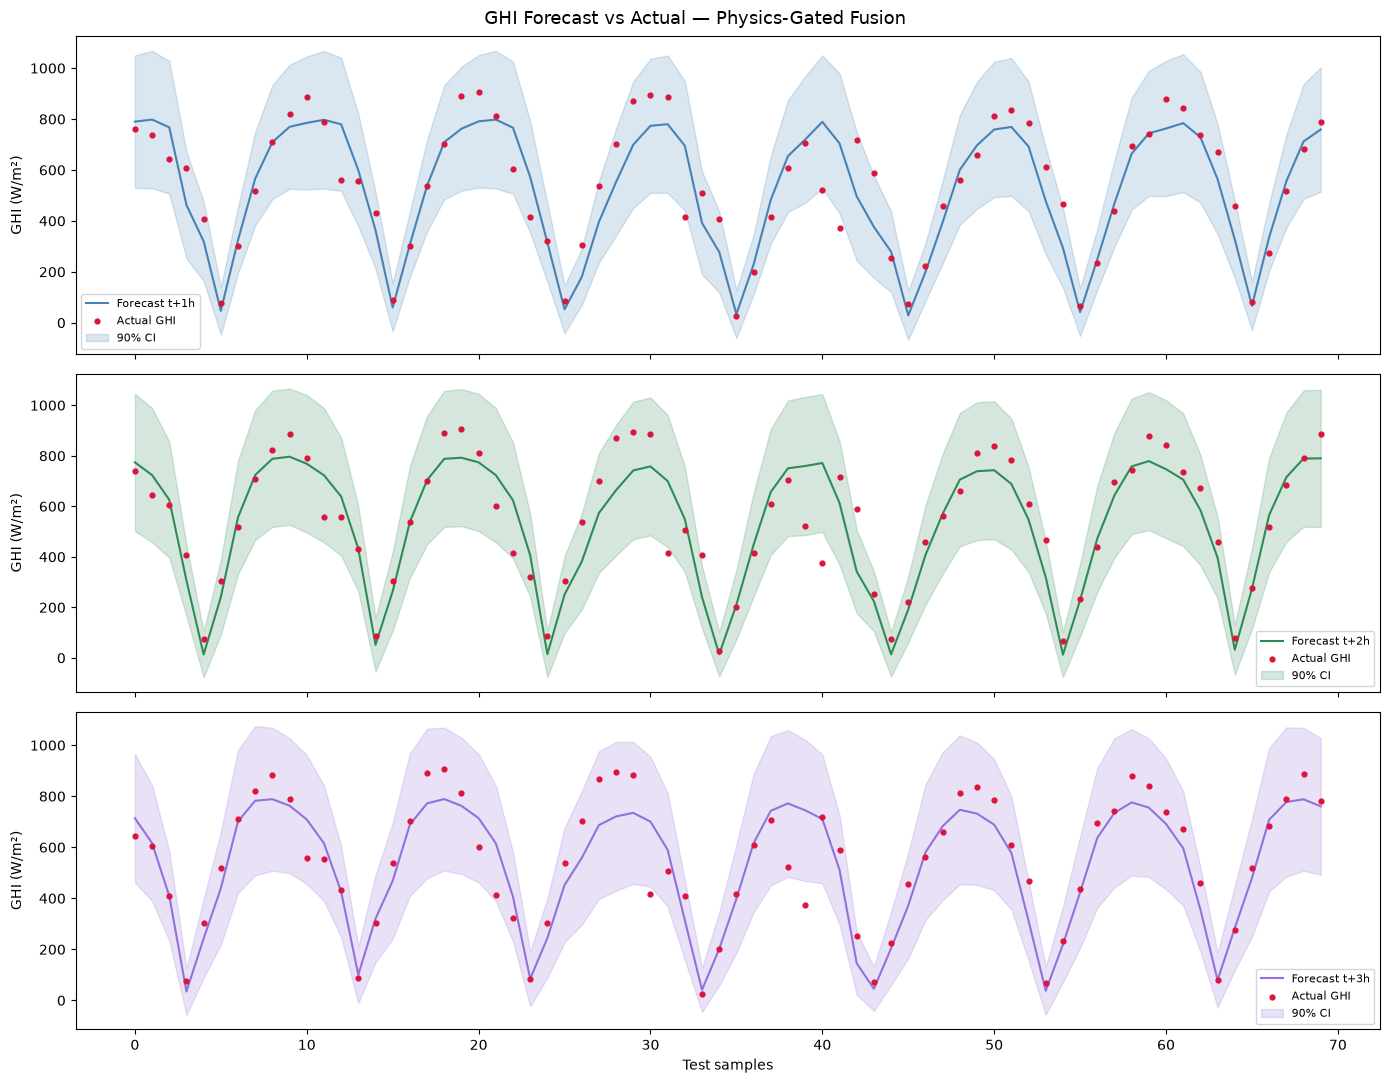

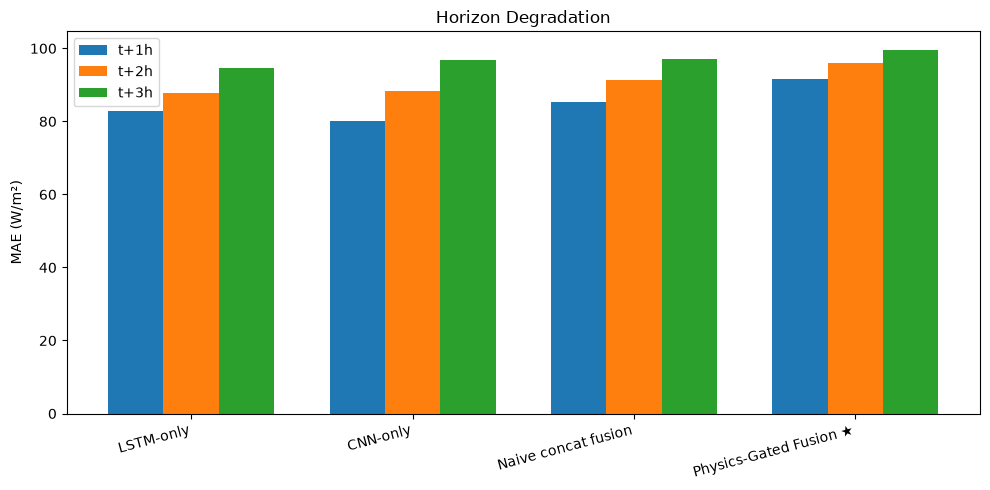

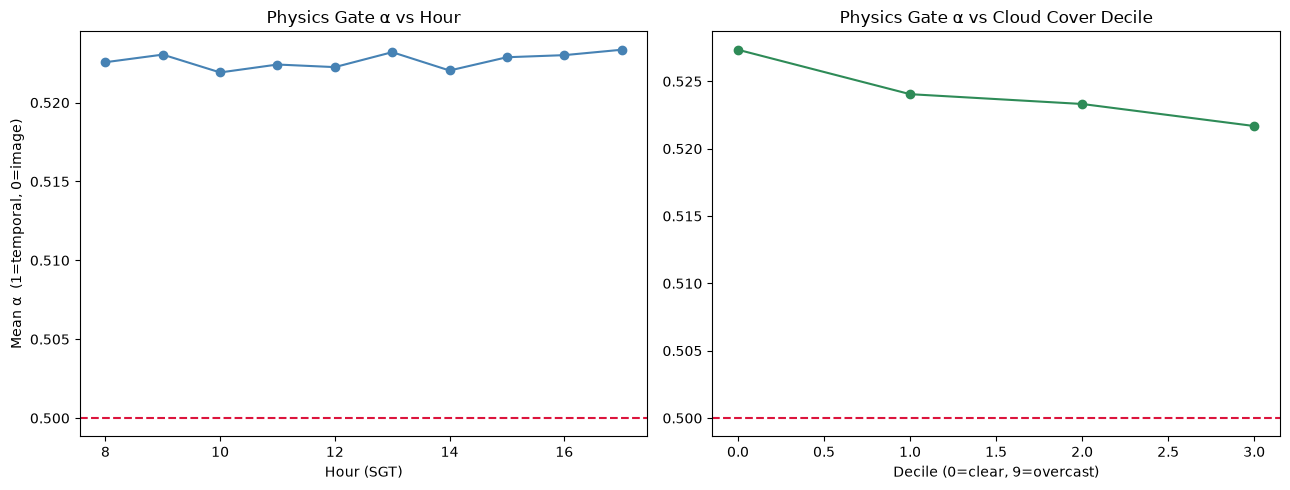

In [18]:
# 9a. Training curves
if history and len(history["train_nll"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["train_nll"], label="Train", lw=2)
    axes[0].plot(history["val_nll"],   label="Val",   lw=2)
    axes[0].set_title("NLL Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history["train_mae"], label="Train", lw=2)
    axes[1].plot(history["val_mae"],   label="Val",   lw=2)
    axes[1].set_title("MAE (W/m²) — t+1h"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{RESULTS}/plots/training_curves.png", dpi=150)
    plt.show()

# 9b. Forecast vs Actual
N = 70
mu_p, sig_p, tar_p = [x[:N] for x in pred_cache["full"]]
fig, axs = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
for h, col in enumerate(["steelblue","seagreen","mediumpurple"]):
    lo = mu_p[:,h] - 1.645*sig_p[:,h]; hi = mu_p[:,h] + 1.645*sig_p[:,h]
    axs[h].plot(mu_p[:,h], color=col, lw=1.5, label=f"Forecast t+{h+1}h")
    axs[h].scatter(range(N), tar_p[:,h], color="crimson", s=12, zorder=5, label="Actual GHI")
    axs[h].fill_between(range(N), lo, hi, alpha=0.2, color=col, label="90% CI")
    axs[h].set_ylabel("GHI (W/m²)"); axs[h].legend(fontsize=8)
axs[2].set_xlabel("Test samples")
plt.suptitle("GHI Forecast vs Actual — Physics-Gated Fusion", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS}/plots/forecast_vs_actual.png", dpi=150); plt.show()

# 9c. Horizon degradation
deep = list(eval_horizons.keys())
h1 = [eval_horizons[n][0]["MAE_Wm2"] for n in deep]
h2 = [eval_horizons[n][1]["MAE_Wm2"] for n in deep]
h3 = [eval_horizons[n][2]["MAE_Wm2"] for n in deep]
x, w = np.arange(len(deep)), 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x-w, h1, w, label="t+1h"); ax.bar(x, h2, w, label="t+2h"); ax.bar(x+w, h3, w, label="t+3h")
ax.set_xticks(x); ax.set_xticklabels(deep, rotation=15, ha="right")
ax.set_ylabel("MAE (W/m²)"); ax.set_title("Horizon Degradation"); ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS}/plots/horizon_degradation.png", dpi=150); plt.show()

# 9d. Physics gate analysis
model_full.eval()
all_alpha, all_hours, all_cloud = [], [], []
with torch.no_grad():
    for batch in test_loader:
        tab = batch["tabular_seq"].to(device)
        mf  = batch["multi_frame"].to(device)
        roi = batch["roi_image"].to(device)
        fc  = batch["future_clearsky"].to(device)
        gf  = batch["gate_features"].to(device)
        _, _, alpha, _ = model_full(tab, mf, roi, fc, gf, return_attn=True)
        all_alpha.append(alpha.cpu().view(-1))
        all_cloud.append(batch["gate_features"][:,1]*100)
        all_hours.append(test_dataset.df.iloc[
            [test_dataset.valid_indices[i] for i in range(len(batch["idx"]))]]["hour"].values)

all_alpha = torch.cat(all_alpha).numpy()
all_cloud = torch.cat(all_cloud).numpy()
all_hours = np.concatenate(all_hours)

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
gdf = pd.DataFrame({"alpha": all_alpha, "hour": all_hours})
hm  = gdf.groupby("hour")["alpha"].mean()
axs[0].plot(hm.index, hm.values, marker="o", color="steelblue")
axs[0].axhline(0.5, color="crimson", linestyle="--")
axs[0].set_title("Physics Gate α vs Hour"); axs[0].set_xlabel("Hour (SGT)")
axs[0].set_ylabel("Mean α  (1=temporal, 0=image)")
cdf = pd.DataFrame({"alpha": all_alpha, "cloud": all_cloud})
cdf["dec"] = pd.qcut(cdf["cloud"], 10, duplicates="drop", labels=False)
cm  = cdf.groupby("dec")["alpha"].mean()
axs[1].plot(cm.index, cm.values, marker="o", color="seagreen")
axs[1].axhline(0.5, color="crimson", linestyle="--")
axs[1].set_title("Physics Gate α vs Cloud Cover Decile")
axs[1].set_xlabel("Decile (0=clear, 9=overcast)")
plt.tight_layout()
plt.savefig(f"{RESULTS}/plots/gate_analysis.png", dpi=150); plt.show()


In [19]:
# ── Save training statistics (required by predict.py / verify.py) ─────────────
import json
stats = {k: v.tolist() if hasattr(v, "tolist") else v for k, v in train_stats.items()}
with open(f"{ROOT}/train_stats.json", "w") as f:
    json.dump(stats, f)
print(f"Saved {ROOT}/train_stats.json ✓")

# ── What to copy back to your project folder after training ───────────────────
print("""
════════════════════════════════════════════════════════════════
  TRAINING COMPLETE — copy these back to your Project folder:
    • best_model.pt          (the model predict.py loads)
    • train_stats.json       (normalisation stats — REQUIRED)
    • results/               (metrics + plots)
    • best_model_lstm/cnn/concat.pt   (optional, ablations)
    • swimseg_encoder.pt     (optional, reusable for future runs)

  Then on your Mac:  python predict.py   →   python verify.py
════════════════════════════════════════════════════════════════
""")

Saved /workspace/train_stats.json ✓

════════════════════════════════════════════════════════════════
  TRAINING COMPLETE — copy these back to your Project folder:
    • best_model.pt          (the model predict.py loads)
    • train_stats.json       (normalisation stats — REQUIRED)
    • results/               (metrics + plots)
    • best_model_lstm/cnn/concat.pt   (optional, ablations)
    • swimseg_encoder.pt     (optional, reusable for future runs)

  Then on your Mac:  python predict.py   →   python verify.py
════════════════════════════════════════════════════════════════

